In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report

import pandas as pnd


<h1 style="color: red;">Section 1: Data</h1>

<h2>1) Préparation de données</h2>

In [22]:
dataset =pnd.read_csv('diabetes.csv')#import
X = np.array(dataset.drop(columns=['Outcome'])) #features
y = np.array(dataset['Outcome']) #target
#spilt data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)


<h1 style="color: red;">Section 2: Neural network avec tensorflow</h1>

In [23]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

from tensorflow.keras.optimizers import Adam

<h2>2) Modèle de réseau de neurones</h2>

In [33]:
model_nn = Sequential()
output_layer = Dense(1, input_shape=(X_train.shape[1],), activation='sigmoid') # Q 2-a-2 et 2-a-3
model_nn.add(output_layer) # Q 2-b
opt = Adam(learning_rate=0.001) # Q 2-c
model_nn.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"]) # Q 2-c
model_nn.fit(X_train, y_train, epochs=1000, verbose=0) # Q 2-d (verbose=0 pour éviter d'imprimer 1000 lignes)

<h2>3) Prédiction en utilisant le modèle</h2>

In [25]:
yhat_nn=model_nn.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [26]:
yhat_nn=yhat_nn.flatten()

In [27]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

# Afficher les poids et biais
print("Poids :", W_nn.flatten())
print("Biais :", bias_nn)

Poids : [ 7.6154374e-02  2.6307125e-02 -2.0337140e-02 -1.2897298e-04
  2.0912812e-04  4.1327655e-02  6.2889147e-01  4.4885343e-03]
Biais : [-4.2662373]


In [28]:
W_nn,bias_nn

(array([[ 7.6154374e-02],
        [ 2.6307125e-02],
        [-2.0337140e-02],
        [-1.2897298e-04],
        [ 2.0912812e-04],
        [ 4.1327655e-02],
        [ 6.2889147e-01],
        [ 4.4885343e-03]], dtype=float32),
 array([-4.2662373], dtype=float32))

<h2>4) Evaluation du modèle</h2>

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step
4-a) Training MSE : 0.16642659902572632
4-a) Training R2 : 0.2686115503311157


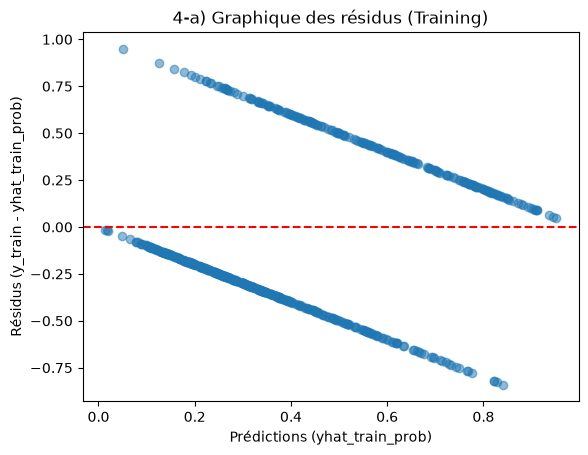

4-b) Test Accuracy : 0.7857142857142857
4-b) Test F1 Score : 0.6732673267326733


In [29]:
#code à fournir
# --- 4-a) Performance du modèle sur training set ---
yhat_train_prob = model_nn.predict(X_train).flatten()

# Évaluer le modèle en utilisant mse, r2 (comme demandé par l'énoncé)
from sklearn.metrics import mean_squared_error, r2_score
print("4-a) Training MSE :", mean_squared_error(y_train, yhat_train_prob))
print("4-a) Training R2 :", r2_score(y_train, yhat_train_prob))

# Calculer y_train - yhat_train_prob et tracer le graphique des résidus
residuals = y_train - yhat_train_prob
plt.scatter(yhat_train_prob, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('4-a) Graphique des résidus (Training)')
plt.xlabel('Prédictions (yhat_train_prob)')
plt.ylabel('Résidus (y_train - yhat_train_prob)')
plt.show()

# --- 4-b) Performance du modèle sur test set ---
# Conversion des probabilités en classes (0 ou 1) pour évaluer l'accuracy
yhat_test_class = (yhat_nn > 0.5).astype(int)
print("4-b) Test Accuracy :", accuracy_score(y_test, yhat_test_class))
print("4-b) Test F1 Score :", f1_score(y_test, yhat_test_class))

<h1>From scratch</h1>


<h2>Modèle de régression logistic from scratch avec utilisation des matrices</h2>


In [30]:
learning_rate = 0.001
epochs = 2000

# Initialisation des paramètres dynamiquement selon le dataset
W = np.zeros((X_train.shape[1], 1))
b = 0.0

# Reshape y_train pour garantir les dimensions adéquates 
y_train = y_train.reshape(-1, 1)
n = len(X_train)

# Entraînement (descente de gradient vectorisée)
for epoch in range(epochs):
    Z = X_train @ W + b
    
    # Safe Sigmoid implementation to prevent numeric overflow/warnings
    Z_clipped = np.clip(Z, -500, 500)
    y_pred = 1 / (1 + np.exp(-Z_clipped))
    
    error = y_pred - y_train

    # Calcul des gradients
    dW = (1 / n) * (X_train.T @ error)
    db = (1 / n) * np.sum(error)

    # Mise à jour des paramètres
    W -= learning_rate * dW
    b -= learning_rate * db

print("Paramètres ajustés :")
print(f"W = \n{W}")
print(f"b = {b:.4f}")

Paramètres ajustés :
W = 
[[ 0.18045769]
 [ 0.05933958]
 [-0.09935649]
 [ 0.00543329]
 [ 0.00699299]
 [-0.01043903]
 [ 0.01518438]
 [-0.01837682]]
b = -0.0747


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# --- 9) Évaluer le modèle custom sur le test set ---
y_test_reshaped = y_test.reshape(-1, 1)

Z_test = X_test @ W + b
Z_test_clipped = np.clip(Z_test, -500, 500)
y_pred_prob_custom = 1 / (1 + np.exp(-Z_test_clipped))

# Conversion probabilités -> classes (0 ou 1) avec un seuil de 0.5
y_pred_class_custom = (y_pred_prob_custom >= 0.5).astype(int)

print("9) Modèle From Scratch - Accuracy :", accuracy_score(y_test_reshaped, y_pred_class_custom))
print("9) Modèle From Scratch - F1 Score :", f1_score(y_test_reshaped, y_pred_class_custom))
print("-" * 40)

# --- 10) Comparer les résultats avec sklearn ---
# Using LogisticRegression because "régression linéaire" in the text is a copy-paste mistake
sk_log_model = LogisticRegression(max_iter=1000)
sk_log_model.fit(X_train, y_train.flatten())

sk_pred_class = sk_log_model.predict(X_test)

print("10) Comparaison avec Sklearn (LogisticRegression) :")
print("Sklearn - Accuracy :", accuracy_score(y_test, sk_pred_class))
print("Sklearn - F1 Score :", f1_score(y_test, sk_pred_class))
print(f"Sklearn b (Intercept) : {sk_log_model.intercept_[0]:.4f}")

9) Modèle From Scratch - Accuracy : 0.6428571428571429
9) Modèle From Scratch - F1 Score : 0.5985401459854015
----------------------------------------
10) Comparaison avec Sklearn (LogisticRegression) :
Sklearn - Accuracy : 0.8051948051948052
Sklearn - F1 Score : 0.6938775510204082
Sklearn b (Intercept) : -8.3415
